# Lab 12: Logistic Regression

## Diabetes Outcome Prediction

This project uses logistic regression to investigate whether patient health measurements can be used to predict a binary diabetes outcome.

The analysis includes:

- Dataset exploration and preparation
- Definition of a binary research question
- Logistic regression model development
- Model accuracy evaluation
- Confusion matrix analysis
- Receiver Operating Characteristic (ROC) curve
- Interpretation of the model results

## 1. Import Required Libraries

The libraries below will be used to load and analyze the dataset, create visualizations, build the logistic regression model, and evaluate its performance.

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting and preprocessing the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import the logistic regression model
from sklearn.linear_model import LogisticRegression

# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Import Path to manage file and folder locations
from pathlib import Path

# Display all DataFrame columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define the Dataset and Output Paths

Relative file paths are used so that the notebook can be run from the project folder without depending on a computer-specific absolute path.

In [2]:
# Identify the project folder containing this notebook
PROJECT_DIR = Path.cwd()

# Define the source Excel file
DATA_FILE = PROJECT_DIR / "Lab 12 - Diabetes.xls"

# Define a folder for model outputs and visualizations
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create the output folder if it does not already exist
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset location: {DATA_FILE}")
print(f"Dataset exists: {DATA_FILE.exists()}")
print(f"Output directory: {OUTPUT_DIR}")

Project directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression
Dataset location: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression\Lab 12 - Diabetes.xls
Dataset exists: True
Output directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression\outputs


## 3. Load the Diabetes Dataset

The diabetes dataset is loaded from the Excel file into a Pandas DataFrame. The first ten records are displayed to confirm that the file was read correctly.

In [3]:
# Load the Excel dataset into a Pandas DataFrame
diabetes_df = pd.read_excel(DATA_FILE)

# Display the first 10 observations
diabetes_df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Load the Excel dataset into a Pandas DataFrame
diabetes_df = pd.read_excel(DATA_FILE)

# Display the first 10 observations
diabetes_df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 4. Examine the Dataset Structure

The shape, column names, and data types are examined to understand the organization of the dataset and confirm that the variables were loaded correctly.

In [8]:
# Display the number of rows and columns
print(f"Number of rows: {diabetes_df.shape[0]}")
print(f"Number of columns: {diabetes_df.shape[1]}")

# Display the column names
print("\nColumn names:")
print(diabetes_df.columns.tolist())

# Display the data type of each column
print("\nData types:")
print(diabetes_df.dtypes)

Number of rows: 768
Number of columns: 9

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


## 5. Review Dataset Information

The `info()` method provides information about the number of observations, data types, and non-null values in each column.

In [9]:
# Display a structural summary of the dataset
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 6. Generate Descriptive Statistics

Descriptive statistics are calculated to examine the central tendency, spread, and range of each numerical variable.

In [10]:
# Display descriptive statistics for all variables
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 7. Check Missing Values and Duplicate Records

Missing values and duplicate rows can affect the quality and reliability of a machine learning model. This step checks for both conditions.

In [11]:
# Count missing values in each column
missing_values = diabetes_df.isnull().sum()

# Count duplicate rows
duplicate_count = diabetes_df.duplicated().sum()

print("Missing values by column:")
print(missing_values)

print(f"\nNumber of duplicate rows: {duplicate_count}")

Missing values by column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Number of duplicate rows: 0


## 8. Examine Potentially Invalid Zero Values

Some medical variables cannot realistically have a value of zero. For example, glucose, blood pressure, skin thickness, insulin, and BMI values of zero may represent missing measurements rather than true observations.

The number of zero values in these variables is examined before preparing the data for modeling.

In [12]:
# Medical variables where zero may represent a missing measurement
zero_check_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count zero values in each selected column
zero_counts = (diabetes_df[zero_check_columns] == 0).sum()

# Calculate the percentage of zero values
zero_percentages = (
    zero_counts / len(diabetes_df) * 100
).round(2)

# Combine the results into a summary table
zero_summary = pd.DataFrame({
    "Zero_Count": zero_counts,
    "Zero_Percentage": zero_percentages
})

zero_summary

,Zero_Count,Zero_Percentage
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


## 9. Examine the Diabetes Outcome Distribution

The distribution of the binary outcome is examined to determine how many patients were classified as having diabetes and how many were classified as not having diabetes.

In [13]:
# Count observations in each outcome category
outcome_counts = diabetes_df["Outcome"].value_counts().sort_index()

# Calculate percentages
outcome_percentages = (
    diabetes_df["Outcome"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Create an outcome summary table
outcome_summary = pd.DataFrame({
    "Count": outcome_counts,
    "Percentage": outcome_percentages
})

# Rename the index values for easier interpretation
outcome_summary.index = ["No Diabetes (0)", "Diabetes (1)"]

outcome_summary

,Count,Percentage
No Diabetes (0),500,65.1
Diabetes (1),268,34.9


## 10. Research Question and Hypotheses

### Research Question

Can pregnancies, glucose level, blood pressure, skin thickness, insulin level, body mass index, diabetes pedigree function, and age be used to predict whether a patient has diabetes?

### Binary Outcome

The target variable is `Outcome`:

- `0` = The patient does not have diabetes
- `1` = The patient has diabetes

### Predictor Variables

The predictor variables are:

- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

### Hypotheses

**Null hypothesis (H₀):** The selected patient health measurements do not significantly improve the prediction of diabetes status.

**Alternative hypothesis (H₁):** At least one of the selected patient health measurements contributes to predicting diabetes status.

## 11. Prepare the Dataset for Modeling

Although the dataset contains no formally recorded null values, zeros in glucose, blood pressure, skin thickness, insulin, and BMI are unlikely to represent valid medical measurements. These zero values are therefore converted to missing values.

Median imputation will later be performed using a scikit-learn pipeline. Median imputation is appropriate because it is less sensitive to extreme values than mean imputation.

In [14]:
# Create a copy so the original DataFrame remains unchanged
model_df = diabetes_df.copy()

# Variables where zero represents an unavailable or invalid measurement
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace invalid zero values with NaN
model_df[invalid_zero_columns] = model_df[
    invalid_zero_columns
].replace(0, np.nan)

# Display the number of missing values after replacement
print("Missing values after replacing invalid zeros:")
print(model_df.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 12. Separate Predictor and Outcome Variables

The independent variables are assigned to `X`, while the binary diabetes outcome is assigned to `y`.

In [15]:
# Define the predictor variables
X = model_df.drop(columns="Outcome")

# Define the binary target variable
y = model_df["Outcome"]

print(f"Predictor matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print("\nPredictor variables:")
print(X.columns.tolist())

Predictor matrix shape: (768, 8)
Target vector shape: (768,)

Predictor variables:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 13. Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing subsets. Eighty percent of the observations are used to train the model, and twenty percent are reserved for evaluation.

Stratification is used so that the proportion of diabetes and non-diabetes cases remains similar in both subsets. A fixed random state is used to make the results reproducible.

In [16]:
# Split the data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training predictor shape: {X_train.shape}")
print(f"Testing predictor shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

print("\nTraining outcome percentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTesting outcome percentages:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Training predictor shape: (614, 8)
Testing predictor shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)

Training outcome percentages:
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Testing outcome percentages:
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64


## 14. Create the Logistic Regression Pipeline

The modeling pipeline performs three operations:

1. Replaces missing medical measurements with the median value calculated from the training data.
2. Standardizes the predictor variables so that they have comparable scales.
3. Fits a logistic regression classifier.

Using a pipeline ensures that preprocessing is learned only from the training data and is then consistently applied to the test data.

In [17]:
# Import preprocessing and pipeline tools
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [18]:
# Create a preprocessing and logistic regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the logistic regression model
logistic_pipeline.fit(X_train, y_train)

print("Logistic regression model trained successfully.")

Logistic regression model trained successfully.


## 15. Generate Predictions

The trained logistic regression model is used to predict diabetes outcomes for the testing dataset. It also generates the probability that each patient belongs to the diabetes class.

In [19]:
# Predict binary outcomes for the test dataset
y_pred = logistic_pipeline.predict(X_test)

# Predict the probability of diabetes, Outcome = 1
y_pred_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print(f"Number of test predictions: {len(y_pred)}")

Predictions generated successfully.
Number of test predictions: 154


## 16. Calculate Model Accuracy

Accuracy represents the proportion of test observations that the logistic regression model classified correctly.

In [20]:
# Calculate model accuracy
model_accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {model_accuracy:.4f}")
print(f"Logistic Regression Accuracy Percentage: {model_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 0.7078
Logistic Regression Accuracy Percentage: 70.78%


## 17. Classification Report

The classification report provides precision, recall, and F1-score for both outcome classes.

- **Precision** measures how many predicted cases in a class were correct.
- **Recall** measures how many actual cases in a class were correctly identified.
- **F1-score** balances precision and recall.

In [21]:
# Generate the classification report as text
classification_results = classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
)

print("Classification Report:")
print(classification_results)

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## 18. Confusion Matrix

The confusion matrix compares actual and predicted diabetes outcomes.

The four possible results are:

- **True Negative:** No diabetes correctly predicted
- **False Positive:** Diabetes incorrectly predicted
- **False Negative:** Diabetes case incorrectly predicted as no diabetes
- **True Positive:** Diabetes correctly predicted

In [22]:
# Calculate the confusion matrix
confusion_mat = confusion_matrix(y_test, y_pred)

# Extract individual confusion matrix values
true_negative, false_positive, false_negative, true_positive = (
    confusion_mat.ravel()
)

print("Confusion Matrix:")
print(confusion_mat)

print(f"\nTrue Negatives: {true_negative}")
print(f"False Positives: {false_positive}")
print(f"False Negatives: {false_negative}")
print(f"True Positives: {true_positive}")

Confusion Matrix:
[[82 18]
 [27 27]]

True Negatives: 82
False Positives: 18
False Negatives: 27
True Positives: 27


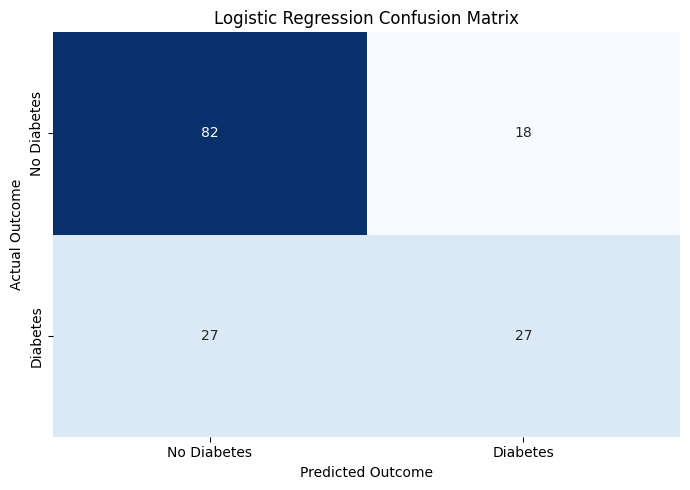

Confusion matrix saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression\outputs\confusion_matrix.png


In [23]:
# Create a visual representation of the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()

# Save the visualization
confusion_matrix_file = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Confusion matrix saved to: {confusion_matrix_file}")

## 19. Calculate Sensitivity and Specificity

Sensitivity measures the model's ability to correctly identify patients with diabetes. Specificity measures its ability to correctly identify patients without diabetes.

In [24]:
# Calculate sensitivity, also called recall for the positive class
sensitivity = true_positive / (true_positive + false_negative)

# Calculate specificity
specificity = true_negative / (true_negative + false_positive)

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Sensitivity: 0.5000
Specificity: 0.8200


## 20. Receiver Operating Characteristic Curve

The Receiver Operating Characteristic, or ROC, curve evaluates the model across different classification thresholds.

The Area Under the Curve, or AUC, summarizes the model's ability to distinguish between patients with and without diabetes. A value closer to 1 indicates stronger classification performance.

In [25]:
# Calculate false-positive and true-positive rates
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

# Calculate the area under the ROC curve
roc_auc = roc_auc_score(y_test, y_pred_probability)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8130


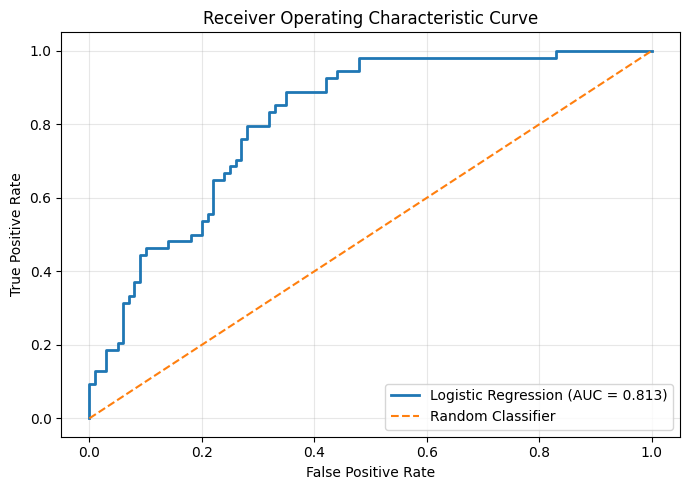

ROC curve saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression\outputs\roc_curve.png


In [26]:
# Plot the ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Plot the no-skill reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Receiver Operating Characteristic Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the visualization
roc_curve_file = OUTPUT_DIR / "roc_curve.png"
plt.savefig(roc_curve_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"ROC curve saved to: {roc_curve_file}")

## 21. Interpret the Logistic Regression Coefficients

Logistic regression coefficients indicate the direction and relative strength of each predictor's relationship with the probability of diabetes.

Because the predictors were standardized, each coefficient represents the change in log-odds associated with a one-standard-deviation increase in the predictor, while the other variables remain constant.

- A positive coefficient indicates a higher predicted probability of diabetes.
- A negative coefficient indicates a lower predicted probability of diabetes.
- An odds ratio greater than 1 indicates increased odds of diabetes.
- An odds ratio less than 1 indicates decreased odds of diabetes.

In [27]:
# Retrieve the trained logistic regression model from the pipeline
trained_logistic_model = logistic_pipeline.named_steps["model"]

# Extract the model coefficients
coefficients = trained_logistic_model.coef_[0]

# Convert coefficients into odds ratios
odds_ratios = np.exp(coefficients)

# Create a coefficient summary table
coefficient_summary = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratios
})

# Add absolute coefficient values for ranking
coefficient_summary["Absolute_Coefficient"] = (
    coefficient_summary["Coefficient"].abs()
)

# Sort predictors from strongest to weakest relationship
coefficient_summary = coefficient_summary.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

# Round values for readability
coefficient_summary[
    ["Coefficient", "Odds_Ratio", "Absolute_Coefficient"]
] = coefficient_summary[
    ["Coefficient", "Odds_Ratio", "Absolute_Coefficient"]
].round(4)

coefficient_summary

,Predictor,Coefficient,Odds_Ratio,Absolute_Coefficient
0,Glucose,1.1826,3.2627,1.1826
1,BMI,0.6887,1.9910,0.6887
2,Pregnancies,0.3774,1.4586,0.3774
3,DiabetesPedigreeFunction,0.2333,1.2628,0.2333
4,Age,0.1478,1.1593,0.1478
5,Insulin,-0.0661,0.9360,0.0661
6,BloodPressure,-0.0441,0.9568,0.0441
7,SkinThickness,0.0283,1.0287,0.0283


## 22. Visualize Predictor Coefficients

The coefficient plot displays the direction and relative magnitude of each predictor's relationship with diabetes prediction.

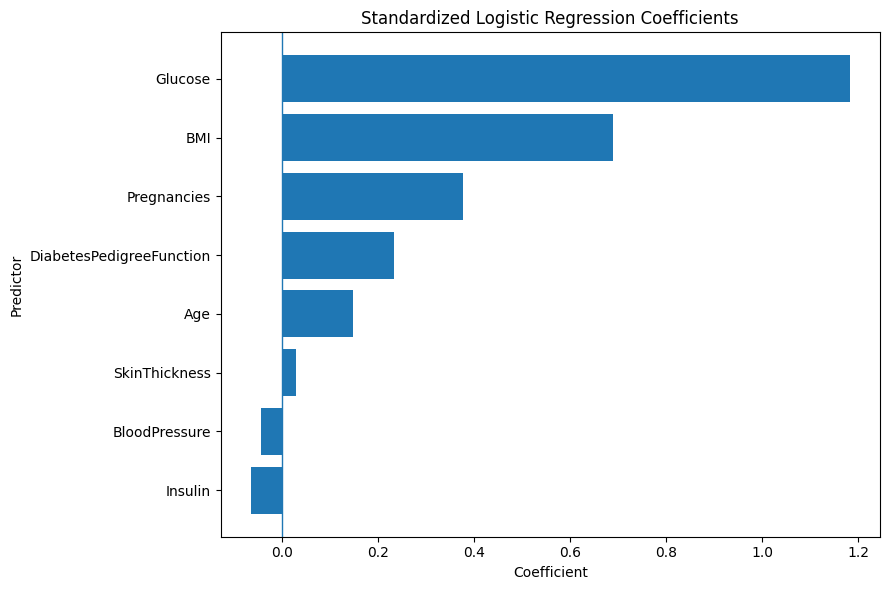

Coefficient plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression\outputs\logistic_regression_coefficients.png


In [28]:
# Sort coefficients for horizontal plotting
coefficient_plot_data = coefficient_summary.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    coefficient_plot_data["Predictor"],
    coefficient_plot_data["Coefficient"]
)

# Add a vertical reference line at zero
plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Standardized Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()

# Save the coefficient plot
coefficient_plot_file = OUTPUT_DIR / "logistic_regression_coefficients.png"
plt.savefig(
    coefficient_plot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Coefficient plot saved to: {coefficient_plot_file}")

## 23. Create a Model Performance Summary

The primary evaluation metrics are combined into a single table for reporting and later export.

In [29]:
# Create a model performance summary table
performance_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "ROC-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Value": [
        model_accuracy,
        sensitivity,
        specificity,
        roc_auc,
        true_negative,
        false_positive,
        false_negative,
        true_positive
    ]
})

performance_summary

,Metric,Value
0,Accuracy,0.707792
1,Sensitivity,0.500000
2,Specificity,0.820000
3,ROC-AUC,0.812963
4,True Negatives,82.000000
5,False Positives,18.000000
6,False Negatives,27.000000
7,True Positives,27.000000


## 24. Save the Analysis Results

The model performance metrics, coefficient summary, and test predictions are saved as CSV files. These files provide reproducible supporting results for the written report.

In [30]:
# Create a table containing actual outcomes, predictions,
# and predicted probabilities for the testing dataset
prediction_results = pd.DataFrame({
    "Actual_Outcome": y_test.reset_index(drop=True),
    "Predicted_Outcome": y_pred,
    "Predicted_Diabetes_Probability": y_pred_probability
})

# Save model results
performance_summary.to_csv(
    OUTPUT_DIR / "logistic_regression_performance.csv",
    index=False
)

coefficient_summary.to_csv(
    OUTPUT_DIR / "logistic_regression_coefficients.csv",
    index=False
)

prediction_results.to_csv(
    OUTPUT_DIR / "logistic_regression_test_predictions.csv",
    index=False
)

print("Analysis results saved successfully.")
print(f"Output folder: {OUTPUT_DIR}")

Analysis results saved successfully.
Output folder: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_12_Logistic_Regression\outputs


## 25. Results Interpretation

The logistic regression model achieved an accuracy of 70.78% on the testing dataset. Out of 154 test observations, the model correctly classified 82 patients without diabetes and 27 patients with diabetes.

The model produced 18 false-positive predictions and 27 false-negative predictions. Its sensitivity was 50.00%, indicating that it correctly identified half of the patients who actually had diabetes. Its specificity was 82.00%, showing that it was more effective at identifying patients who did not have diabetes.

The ROC-AUC score was 0.8130. This result indicates that the model had good overall ability to distinguish between patients with and without diabetes across different probability thresholds.

Although the accuracy was higher than the 65.10% majority-class baseline, accuracy alone does not fully describe model performance because the outcome classes were moderately imbalanced. The relatively low sensitivity is especially important in a healthcare setting because false-negative predictions could result in patients with diabetes not receiving additional testing or timely intervention.

## 26. Conclusion

This analysis investigated whether patient health measurements could be used to predict a binary diabetes outcome. A logistic regression model was developed using pregnancies, glucose, blood pressure, skin thickness, insulin, BMI, diabetes pedigree function, and age as predictor variables.

The model achieved 70.78% accuracy and an ROC-AUC score of 0.8130. These results suggest that the selected health measurements contain meaningful information for distinguishing between patients with and without diabetes. The model was more successful at identifying patients without diabetes than patients with diabetes, as demonstrated by its 82.00% specificity and 50.00% sensitivity.

The model could serve as a preliminary risk-screening tool, but it should not be used as a substitute for clinical diagnosis. In a real healthcare application, improving sensitivity would be important because failing to identify a patient with diabetes may have greater consequences than incorrectly recommending additional screening. Future work could evaluate alternative classification thresholds, class-weighted logistic regression, additional patient information, and other machine learning algorithms.

## 27. Interpretation of Predictor Effects

The standardized logistic regression coefficients provide information about the direction and relative strength of each predictor.

- **Glucose** was the strongest predictor. A one-standard-deviation increase in glucose was associated with approximately 3.26 times greater predicted odds of diabetes, holding the other predictors constant.
- **BMI** was the second strongest predictor. A one-standard-deviation increase in BMI was associated with approximately 1.99 times greater predicted odds of diabetes.
- **Pregnancies** had an odds ratio of approximately 1.46, indicating increased predicted diabetes odds as the number of pregnancies increased.
- **DiabetesPedigreeFunction** had an odds ratio of approximately 1.26, suggesting that greater hereditary diabetes risk was associated with higher predicted odds of diabetes.
- **Age** had a smaller positive relationship, with an odds ratio of approximately 1.16.
- **Insulin** and **BloodPressure** had small negative coefficients, with odds ratios slightly below 1.
- **SkinThickness** had a coefficient close to zero, indicating a relatively weak relationship with the predicted outcome after accounting for the other variables.

Overall, glucose and BMI contributed most strongly to the model's diabetes predictions. These coefficients describe predictive relationships and should not automatically be interpreted as evidence of causation or statistical significance.

## 28. Supporting References

Centers for Disease Control and Prevention. (2024). *Diabetes basics*. https://www.cdc.gov/diabetes/about/index.html

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (2026). *Logistic regression*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Scikit-learn developers. (2026). *Classification metrics*. Scikit-learn documentation. https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

Smith, J. W., Everhart, J. E., Dickson, W. C., Knowler, W. C., & Johannes, R. S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In *Proceedings of the Symposium on Computer Applications and Medical Care* (pp. 261–265).

In [31]:
# Confirm that all expected output files were created
expected_output_files = [
    OUTPUT_DIR / "confusion_matrix.png",
    OUTPUT_DIR / "roc_curve.png",
    OUTPUT_DIR / "logistic_regression_coefficients.png",
    OUTPUT_DIR / "logistic_regression_performance.csv",
    OUTPUT_DIR / "logistic_regression_coefficients.csv",
    OUTPUT_DIR / "logistic_regression_test_predictions.csv"
]

print("Generated output files:\n")

for output_file in expected_output_files:
    status = "Created" if output_file.exists() else "Missing"
    print(f"{status}: {output_file.name}")

Generated output files:

Created: confusion_matrix.png
Created: roc_curve.png
Created: logistic_regression_coefficients.png
Created: logistic_regression_performance.csv
Created: logistic_regression_coefficients.csv
Created: logistic_regression_test_predictions.csv


## 29. Final Project Summary

This notebook completed the following tasks:

1. Loaded and examined the diabetes dataset.
2. Identified invalid zero values in selected medical variables.
3. Converted invalid zeros to missing values.
4. Applied median imputation and predictor standardization.
5. Split the data into stratified training and testing subsets.
6. Trained a logistic regression classification model.
7. Evaluated the model using accuracy, precision, recall, F1-score, sensitivity, specificity, a confusion matrix, and an ROC curve.
8. Interpreted standardized coefficients and odds ratios.
9. Saved visualizations, predictions, coefficients, and performance results.

The final model achieved:

- **Accuracy:** 70.78%
- **Sensitivity:** 50.00%
- **Specificity:** 82.00%
- **ROC-AUC:** 0.8130
- **Strongest predictors:** Glucose and BMI